# Why does the `word_length` × RT correlation differ between sentences and paragraphs?

**Context.** A reader of *Readability Formulas, Systems and LLMs are Poor Predictors of Reading Ease* wrote in to ask:

> *We were surprised to see the big difference in correlations between, for example, word length in passages and in sentences. We assumed that since the mean of word length overall stays the same, there should not be that big of a difference. Would you be able to clarify how this calculation works or point us to the relevant part of your code?*

This notebook is the answer. It (1) shows that the means really are essentially identical at both resolutions, (2) shows that the **variance / range** of `word_length` is very different between sentences and paragraphs, (3) recomputes the correlations from scratch to confirm the stored numbers, and (4) explains why a metric whose **mean** is preserved by aggregation can still produce a meaningfully different **correlation** with reading time when you change the unit of analysis.

## TL;DR

1. **The means are essentially identical** at both resolutions: both are computed by the same function ([`add_word_freq_and_len`](../../../readability_metrics/add_metrics.py#L79)) — `text.split()`, strip punctuation, then `mean(len(word))`. For paragraphs it's run once on the whole paragraph text (so it's the average word length over all the paragraph's words); for sentences it's run once per aligned sentence (the average word length over that sentence's words). The population mean comes out almost identical at the two resolutions (Adv ≈ 4.77, Ele ≈ 4.58 chars/word).
2. **But the variance differs by ~2×.** At the `diff` (Adv − Ele) level the standard deviation is **0.42** for sentences and **0.19** for paragraphs; the range is **[−1.28, 1.96]** for sentences and **[−0.30, 0.81]** for paragraphs. Each paragraph value averages over many tokens (often hundreds), so per-paragraph fluctuations of the mean shrink ~√n relative to per-sentence fluctuations.
3. **Sample sizes also differ.** N ≈ 790 aligned sentence pairs vs N = 162 paragraph pairs — about 5× more rows on the sentence side.
4. **Consequence for Pearson r.** Pearson is invariant to scale but sensitive to the *joint* distribution. With more spread in the predictor and 5× more observations, sentence-level correlations are larger in absolute value for `word_length` × RT (e.g. Pearson r = 0.41 sent vs 0.33 par for `mean_nonzero_TF`; 0.40 vs 0.33 for `SkipRateTotal`). The stored numbers are correct — there is no pipeline bug.
5. **Interpretation.** The two correlations answer two different questions. *Paragraph-level r* asks: across paragraphs, does a paragraph whose Adv→Ele simplification shortens average word length more also speed up reading more? *Sentence-level r* asks the same at the sentence resolution, where each aligned sentence pair contributes its own observation. Both are valid; they differ because the sentence-level signal exposes within-paragraph variability that the paragraph average smooths away.

---

## 1. Setup

We use the same readability/RT files that produce the bars in Figure 1 of the paper:

* `src/readability_metrics/data/{sentences,paragraphs}_metrics_cleaned.csv` — per-text metric values used for the rain-cloud distributions.
* `src/Correlations/L1_and_L2/FirstReading/RT_all_metrics_df_{sentence,paragraph}.csv` — wide tables joining `Adv_*` / `Ele_*` / `diff_*` metric values to RT measures, one row per text (or per aligned sentence). These are the inputs the correlation pipeline reads.
* `src/Correlations/L1_and_L2/FirstReading/agg_folds_corr_{sentence,paragraph}.csv` — the stored Pearson/Spearman correlations and bootstrap intervals plotted in Figure 1.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, ttest_ind

# Run from repo root so that the existing helpers import cleanly
REPO_ROOT = Path('/data/home/gkeren/Readability')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

READER  = 'L1_and_L2'        # which reader subgroup the main fig uses
REGIME  = 'FirstReading'     # reading regime
RESULT_DIR = REPO_ROOT / f'src/Correlations/{READER}/{REGIME}'
METRIC_DIR = REPO_ROOT / 'src/readability_metrics/data'

# Three RT measures used in the main figure of the paper.
MAIN_RT_COLS = ['mean_nonzero_TF', 'SkipRateTotal', 'RegRateTotal']
RT_LABELS = {
    'mean_nonzero_TF': 'Total Fixation(TF)',
    'SkipRateTotal':   'Skip Rate (SR)',
    'RegRateTotal':    'Regression Rate (RR)',
}
print('result dir:', RESULT_DIR)
print('metric dir:', METRIC_DIR)

result dir: /data/home/gkeren/Readability/src/Correlations/L1_and_L2/FirstReading
metric dir: /data/home/gkeren/Readability/src/readability_metrics/data


## 2. The `word_length` distribution at sentence vs paragraph resolution

First, the raw distributions. We load both `*_metrics_cleaned.csv` files, label each row with its resolution and level (Original = `Adv`, Simplified = `Ele`), and then plot a four-row raincloud per metric (Original Para / Original Sent / Simplified Para / Simplified Sent). Significance brackets compare paragraphs vs sentences within each level using Welch's t-test (independent samples, unequal variances).

In [2]:
sent_metrics = pd.read_csv(METRIC_DIR / 'sentences_metrics_cleaned.csv')
para_metrics = pd.read_csv(METRIC_DIR / 'paragraphs_metrics_cleaned.csv')
sent_metrics['resolution'] = 'sentence'
para_metrics['resolution'] = 'paragraph'
common = [c for c in sent_metrics.columns if c in para_metrics.columns]
metrics_long = pd.concat([sent_metrics[common], para_metrics[common]], ignore_index=True)
metrics_long['group'] = metrics_long['level'].astype(str) + '_' + metrics_long['resolution'].astype(str)
print('rows per group:')
print(metrics_long['group'].value_counts())

rows per group:
group
Adv_sentence     884
Ele_sentence     790
Adv_paragraph    162
Ele_paragraph    162
Name: count, dtype: int64


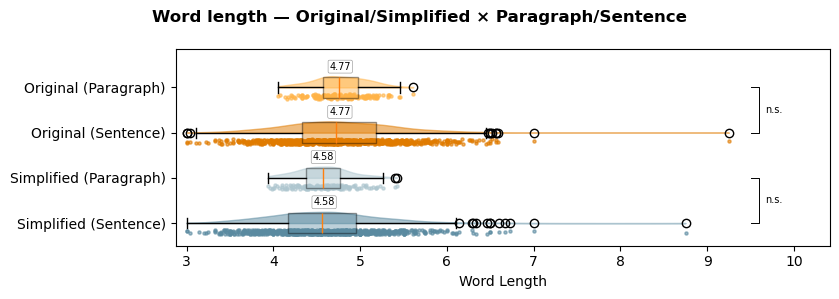

In [17]:
# Use the helpers built in src/readability_metrics/plot_funcs/plot_rain_clouds.py
from src.utils.plot_utils import custom_raincloud_plot
from src.readability_metrics.plot_funcs.plot_rain_clouds import (
    COMBINED_GROUP_ORDER, COMBINED_GROUP_COLORS, COMBINED_GROUP_LABELS,
    _format_p_value_short,
)

def four_row_raincloud(df, col, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 3.0))
    else:
        fig = ax.figure
    ordered_colors = {g: COMBINED_GROUP_COLORS[g] for g in COMBINED_GROUP_ORDER}
    ordered_labels = {g: COMBINED_GROUP_LABELS[g] for g in COMBINED_GROUP_ORDER}
    custom_raincloud_plot(df, [col], {col: title}, [ax],
                          group_colors=ordered_colors, group_labels=ordered_labels,
                          group_col='group')
    # mean labels above each box
    for idx, grp in enumerate(COMBINED_GROUP_ORDER):
        vals = df[df['group']==grp][col].dropna()
        if len(vals) == 0:
            continue
        m = vals.mean()
        ax.text(m, idx + 1.35, f'{m:.2f}', ha='center', va='bottom', fontsize=7,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.15', alpha=0.9, linewidth=0.4),
                zorder=10)
    # within-level Para vs Sent significance brackets on the right
    sig_pairs = [('Ele_sentence','Ele_paragraph',1,2),
                 ('Adv_sentence','Adv_paragraph',3,4)]
    x_lo, x_hi = ax.get_xlim(); span = x_hi - x_lo
    bracket_x = x_hi + span*0.02; tick_x = bracket_x + span*0.015; text_x = tick_x + span*0.01
    for g1, g2, y1, y2 in sig_pairs:
        v1 = df[df['group']==g1][col].dropna(); v2 = df[df['group']==g2][col].dropna()
        if len(v1) < 2 or len(v2) < 2:
            continue
        _, p = ttest_ind(v1, v2, equal_var=False, nan_policy='omit')
        ax.plot([bracket_x, tick_x, tick_x, bracket_x], [y1,y1,y2,y2],
                color='black', lw=0.7, clip_on=False)
        ax.text(text_x, (y1+y2)/2, _format_p_value_short(p),
                ha='left', va='center', fontsize=7, clip_on=False)
    ax.set_xlim(x_lo, x_hi + span*0.16)
    ax.set_ylim(0.5, len(COMBINED_GROUP_ORDER) + 0.85)
    return fig, ax

fig, ax = four_row_raincloud(metrics_long, 'word_length', 'Word Length')
fig.suptitle('Word length — Original/Simplified × Paragraph/Sentence', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Means are nearly identical, variance is not

The plot above already shows it visually; this cell quantifies it. For each `(level, resolution)` cell we report n, mean, SD, and range. Notice that the means are essentially identical, but the SD doubles from paragraphs to sentences, and the sentence range is roughly 4× wider.

Mechanical reason: paragraph `word_length` is computed by [`add_word_freq_and_len`](../../../readability_metrics/add_metrics.py#L79) on the full paragraph text — `text.split()` over all the paragraph's words, then `mean(len(word))` — i.e. the **average word length** of the paragraph. Sentence `word_length` calls the *same* function on each aligned sentence ([`add_freq_and_len_to_aligned`](../../../readability_metrics/add_metrics_aligned.py#L18)) — the **average word length** of that one sentence. So both are average word lengths, just computed over a different number of words (a paragraph contains many sentences' worth of words; a sentence contains few). Averaging over many words preserves the population mean but shrinks per-paragraph fluctuations of the mean roughly as 1/√n — the same reason a sample mean's standard error shrinks with sample size.

In [4]:
stats = []
for grp in ['Adv_paragraph', 'Adv_sentence', 'Ele_paragraph', 'Ele_sentence']:
    v = metrics_long[metrics_long['group']==grp]['word_length'].dropna()
    stats.append({'group': grp, 'n': len(v), 'mean': v.mean(),
                  'std': v.std(), 'min': v.min(), 'max': v.max(),
                  'range': v.max() - v.min()})
summary = pd.DataFrame(stats).set_index('group')
summary

,n,mean,std,min,max,range
group,,,,,,
Adv_paragraph,162,4.7709,0.3092,4.0588,5.6119,1.5531
Adv_sentence,884,4.7671,0.6615,3.0000,9.2500,6.2500
Ele_paragraph,162,4.5763,0.3034,3.9405,5.4225,1.4821
Ele_sentence,790,4.5849,0.6437,3.0000,8.7500,5.7500


In [5]:
# Same statistics for the *paired* diff (Adv − Ele) at each resolution.
# This is the variable that actually feeds the diff-level Pearson correlation.
rt_sent = pd.read_csv(RESULT_DIR / 'RT_all_metrics_df_sentence.csv')
rt_par  = pd.read_csv(RESULT_DIR / 'RT_all_metrics_df_paragraph.csv')
diff_summary = []
for resolution, df in [('sentence', rt_sent), ('paragraph', rt_par)]:
    v = df['diff_word_length'].dropna()
    diff_summary.append({'resolution': resolution, 'n': len(v), 'mean': v.mean(),
                         'std': v.std(), 'min': v.min(), 'max': v.max()})
pd.DataFrame(diff_summary).set_index('resolution')

,n,mean,std,min,max
resolution,,,,,
sentence,790,0.2021,0.4244,-1.2826,1.9597
paragraph,162,0.1946,0.1927,-0.2950,0.8047


## 4. The stored `word_length` × RT correlations

These are the bar heights from the main figure of the paper. We pull them straight from `agg_folds_corr_*.csv` for both resolutions. `pearson_corr_boot` and `spearman_corr_boot` are the bootstrapped point estimates; `pearson_p_boot_symbol` is the discretised significance star.

In [6]:
agg_sent = pd.read_csv(RESULT_DIR / 'agg_folds_corr_sentence.csv')
agg_par  = pd.read_csv(RESULT_DIR / 'agg_folds_corr_paragraph.csv')

def slice_word_length(df, res):
    sub = df[(df['text_col']=='word_length') & (df['level_type']=='diff') & (df['pred_col'].isin(MAIN_RT_COLS))]
    cols = ['pred_col','pearson_corr_boot','spearman_corr_boot',
            'pearson_p_boot_symbol','spearman_p_boot_symbol','n_bootstraps']
    sub = sub[cols].copy(); sub.insert(0, 'resolution', res)
    return sub

stored = pd.concat([slice_word_length(agg_sent, 'sentence'),
                    slice_word_length(agg_par,  'paragraph')], ignore_index=True)
stored

,resolution,pred_col,pearson_corr_boot,spearman_corr_boot,pearson_p_boot_symbol,spearman_p_boot_symbol,n_bootstraps
0,sentence,mean_nonzero_TF,0.4081,0.3610,***,***,200
1,sentence,SkipRateTotal,0.3986,0.3323,***,***,200
2,sentence,RegRateTotal,0.1289,0.1048,*,*,200
3,paragraph,mean_nonzero_TF,0.3323,0.2772,**,*,200
4,paragraph,SkipRateTotal,0.3284,0.3126,**,**,200
5,paragraph,RegRateTotal,0.1596,0.1254,ns,ns,200


In [7]:
# Compact pivot: Pearson r for word_length × RT, sentence vs paragraph, side by side.
pivot = stored.pivot_table(index='pred_col', columns='resolution',
                           values=['pearson_corr_boot','spearman_corr_boot'])
# Order rows so the three main RT measures show first.
ordered_idx = [rt for rt in MAIN_RT_COLS if rt in pivot.index]
pivot = pivot.reindex(ordered_idx)
pivot.round(3)

pearson_corr_boot          spearman_corr_boot         
resolution              paragraph sentence          paragraph sentence
pred_col                                                              
mean_nonzero_TF            0.3320   0.4080             0.2770   0.3610
SkipRateTotal              0.3280   0.3990             0.3130   0.3320
RegRateTotal               0.1600   0.1290             0.1250   0.1050

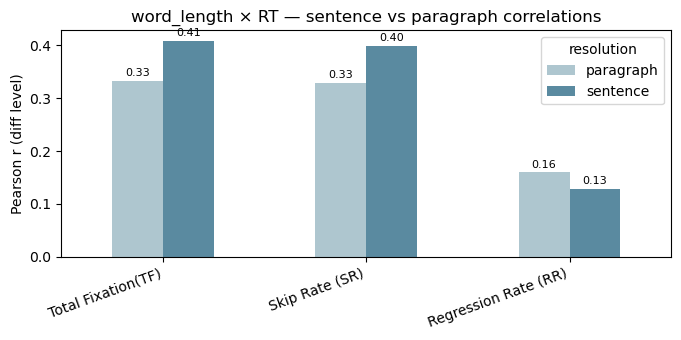

In [8]:
# Visualise the gap as a paired bar chart for the three main RT measures.
main_pivot = stored[stored['pred_col'].isin(MAIN_RT_COLS)].pivot_table(
    index='pred_col', columns='resolution', values='pearson_corr_boot')
main_pivot = main_pivot.reindex(MAIN_RT_COLS)
ax = main_pivot.plot(kind='bar', figsize=(7, 3.5), color={'sentence':'#5A8AA0','paragraph':'#AEC6CF'})
ax.set_ylabel('Pearson r (diff level)')
ax.set_xlabel('')
ax.set_title('word_length × RT — sentence vs paragraph correlations')
ax.set_xticklabels([RT_LABELS.get(c, c) for c in main_pivot.index], rotation=20, ha='right')
ax.axhline(0, color='gray', lw=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

## 5. Sanity check — recompute the correlations directly from `RT_all_metrics_df`

If the stored numbers are correct, computing Pearson / Spearman in this notebook from the underlying `RT_all_metrics_df_*.csv` should reproduce the values in `agg_folds_corr_*.csv` to several decimals. (`pearson_corr_all` is the full-sample estimate; `pearson_corr_boot` is the bootstrap mean. They are very close at this N.)

In [9]:
def recompute(df, rt_col, text_col='word_length'):
    pc = f'diff_{rt_col}'
    tc = f'diff_{text_col}'
    if pc not in df.columns or tc not in df.columns:
        return None
    sub = df[[pc, tc]].dropna()
    if len(sub) < 3:
        return None
    r_p, p_p = pearsonr(sub[pc], sub[tc])
    r_s, p_s = spearmanr(sub[pc], sub[tc])
    return {'n': len(sub), 'pearson_r': r_p, 'pearson_p': p_p,
            'spearman_r': r_s, 'spearman_p': p_s}

recompute_rows = []
for resolution, df in [('sentence', rt_sent), ('paragraph', rt_par)]:
    for rt in MAIN_RT_COLS:
        result = recompute(df, rt)
        if result is None:
            continue
        result.update({'resolution': resolution, 'pred_col': rt})
        recompute_rows.append(result)
recomputed = pd.DataFrame(recompute_rows).set_index(['resolution','pred_col']).sort_index()
recomputed.round(4)

n  pearson_r  pearson_p  spearman_r  spearman_p
resolution pred_col                                                          
paragraph  RegRateTotal     162     0.1658     0.0350      0.1259      0.1104
           SkipRateTotal    162    -0.3370     0.0000     -0.3215      0.0000
           mean_nonzero_TF  162     0.3369     0.0000      0.2771      0.0004
sentence   RegRateTotal     790     0.1320     0.0002      0.1085      0.0023
           SkipRateTotal    790    -0.4012     0.0000     -0.3363      0.0000
           mean_nonzero_TF  790     0.4078     0.0000      0.3615      0.0000

In [10]:
# Compare against stored pearson_corr_all / spearman_corr_all (the full-sample numbers).
# Note: the pipeline stores |r| (always positive) so the bars in the main figure are positive;
# we therefore compare absolute values to confirm the magnitudes match.
stored_all = pd.concat([
    agg_sent[(agg_sent['text_col']=='word_length') & (agg_sent['level_type']=='diff')]
        .assign(resolution='sentence'),
    agg_par [(agg_par ['text_col']=='word_length') & (agg_par ['level_type']=='diff')]
        .assign(resolution='paragraph'),
])[['resolution','pred_col','pearson_corr_all','spearman_corr_all']]
comparison = recomputed.reset_index().merge(stored_all, on=['resolution','pred_col'], how='left')
comparison['pearson_diff']  = comparison['pearson_r'].abs()  - comparison['pearson_corr_all']
comparison['spearman_diff'] = comparison['spearman_r'].abs() - comparison['spearman_corr_all']
print('max abs Pearson difference (|recomputed| vs stored):',  comparison['pearson_diff'].abs().max())
print('max abs Spearman difference (|recomputed| vs stored):', comparison['spearman_diff'].abs().max())
comparison[['resolution','pred_col','pearson_r','pearson_corr_all','pearson_diff',
            'spearman_r','spearman_corr_all','spearman_diff']].round(4)

max abs Pearson difference (|recomputed| vs stored): 1.3877787807814457e-16
max abs Spearman difference (|recomputed| vs stored): 3.484133640888065e-06


,resolution,pred_col,pearson_r,pearson_corr_all,pearson_diff,spearman_r,spearman_corr_all,spearman_diff
0,paragraph,RegRateTotal,0.1658,0.1658,-0.0000,0.1259,0.1259,0.0000
1,paragraph,SkipRateTotal,-0.3370,0.3370,0.0000,-0.3215,0.3215,0.0000
2,paragraph,mean_nonzero_TF,0.3369,0.3369,0.0000,0.2771,0.2771,0.0000
3,sentence,RegRateTotal,0.1320,0.1320,0.0000,0.1085,0.1085,-0.0000
4,sentence,SkipRateTotal,-0.4012,0.4012,0.0000,-0.3363,0.3363,0.0000
5,sentence,mean_nonzero_TF,0.4078,0.4078,0.0000,0.3615,0.3615,0.0000


## 6. Rain clouds for the main RT measures

For symmetry: how do the RT measures themselves look at sentence vs paragraph resolution? Each row in `RT_all_metrics_df_*` already pairs an Adv text with its Ele counterpart, so we can melt to long format with the same `level × resolution` grouping and reuse the four-row raincloud.

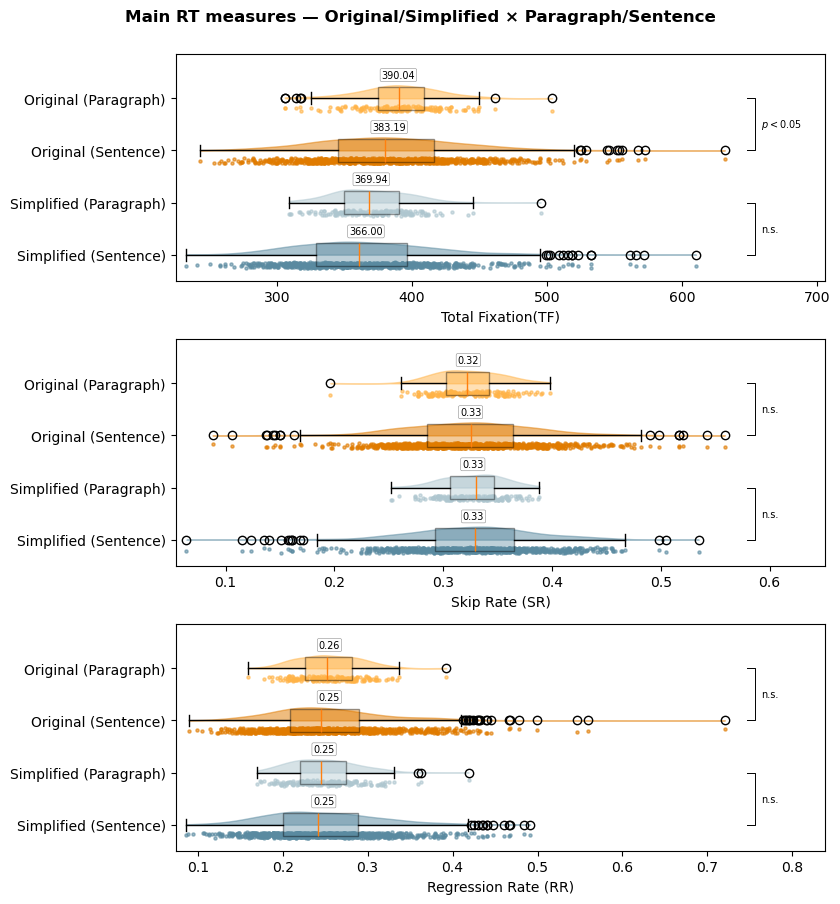

In [11]:
def melt_rt_long(rt_sent, rt_par, rt_col):
    parts = []
    for resolution, df in [('sentence', rt_sent), ('paragraph', rt_par)]:
        for level_letter in ['Adv', 'Ele']:
            col = f'{level_letter}_{rt_col}'
            if col not in df.columns:
                continue
            tmp = df[[col]].rename(columns={col: rt_col}).dropna()
            tmp['level'] = level_letter
            tmp['resolution'] = resolution
            parts.append(tmp)
    long = pd.concat(parts, ignore_index=True)
    long['group'] = long['level'] + '_' + long['resolution']
    return long

fig, axes = plt.subplots(len(MAIN_RT_COLS), 1, figsize=(8.5, 3.0 * len(MAIN_RT_COLS)))
for ax, rt in zip(axes, MAIN_RT_COLS):
    long = melt_rt_long(rt_sent, rt_par, rt)
    four_row_raincloud(long, rt, RT_LABELS.get(rt, rt), ax=ax)
fig.suptitle('Main RT measures — Original/Simplified × Paragraph/Sentence', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

## 7. Why the correlations differ — the joint distribution

Pearson r captures the linear relationship between two variables. It is invariant to additive shifts and multiplicative rescalings of either axis (so the *means* don't enter the formula directly), but it does depend on the **shape of the joint distribution** — concretely on Cov(X, Y) / (σ_X · σ_Y). What changes between resolutions:

* **σ_X (predictor SD).** Sentence-level `diff_word_length` SD = ~0.42 vs paragraph SD = ~0.19. More than 2× more spread on the X axis.
* **Range of X.** Sentence range ≈ [−1.3, +2.0], paragraph range ≈ [−0.3, +0.8]. Sentences see Adv→Ele simplifications that change average word length much more dramatically; paragraphs average those swings out.
* **σ_Y (RT SD).** Same direction — sentence-level RT differences are also more variable than paragraph-level ones.
* **N.** ~790 sentence pairs vs 162 paragraph pairs. More observations don't change the population r but do reduce sampling noise.

The scatter plots below visualise this. The sentence cloud (left) covers a wider rectangle along both axes, with more points reinforcing the linear trend. The paragraph cloud (right) is compressed into a smaller box around the origin — the slope is similar, but with less spread on either axis the same regression line explains a smaller fraction of variance.

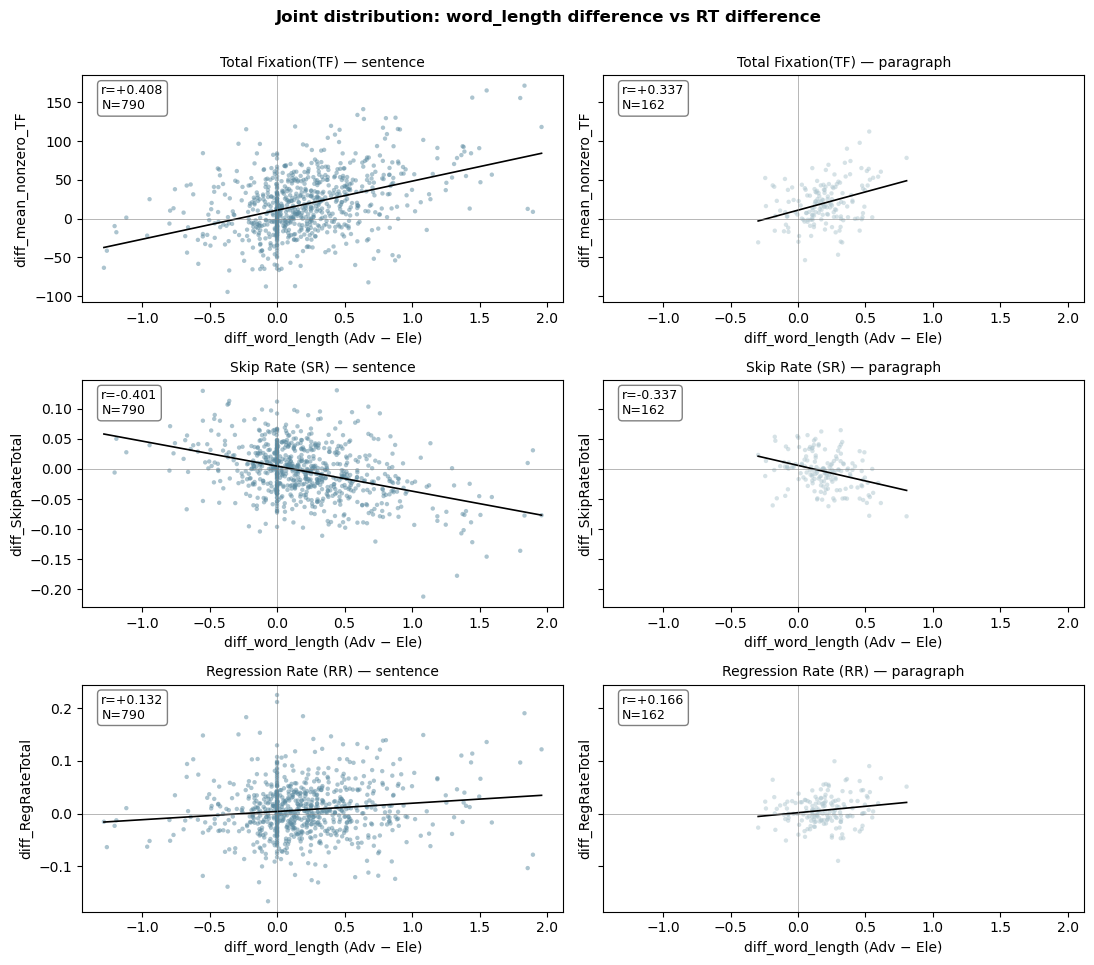

In [12]:
fig, axes = plt.subplots(len(MAIN_RT_COLS), 2, figsize=(11, 3.2 * len(MAIN_RT_COLS)),
                          sharex='row', sharey='row')
for row_axes, rt in zip(axes, MAIN_RT_COLS):
    ax_s, ax_p = row_axes
    for ax, df, res, color in [(ax_s, rt_sent, 'sentence', '#5A8AA0'),
                                (ax_p, rt_par,  'paragraph', '#AEC6CF')]:
        x = df['diff_word_length']
        y = df[f'diff_{rt}']
        m = x.notna() & y.notna()
        x = x[m]; y = y[m]
        ax.scatter(x, y, s=10, alpha=0.5, color=color, edgecolor='none')
        # OLS line
        if len(x) > 2:
            slope, intercept = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 50)
            ax.plot(xs, slope*xs + intercept, color='black', lw=1.2)
            r, p = pearsonr(x, y)
            ax.text(0.04, 0.96, f'r={r:+.3f}\nN={len(x)}',
                    transform=ax.transAxes, va='top', ha='left', fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))
        ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
        ax.set_title(f'{RT_LABELS.get(rt, rt)} — {res}', fontsize=10)
        ax.set_xlabel('diff_word_length (Adv − Ele)')
        ax.set_ylabel(f'diff_{rt}')
fig.suptitle('Joint distribution: word_length difference vs RT difference', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

## 8. Aggregation experiment — averaging sentences back to paragraphs

Direct demonstration that the difference is driven by the unit of analysis, not by any computation specific to one resolution. We take the sentence-level RT table, group its sentences back by their parent text/paragraph (`text_id`), and average both `diff_word_length` and `diff_<RT>` within each parent. The resulting per-parent correlation collapses towards the paragraph-level number.

**Caveat about the aggregation mechanic.** This is *not* exactly the paragraph-level pipeline. The paragraph CSV computes the average word length over all words in the paragraph; here we take the unweighted mean of the sentence-level diffs. The two are not identical when sentences within a paragraph differ in word count. For `word_length` they agree to within ~0.1 chars on average (cell at the bottom of §9 quantifies this), so the demo is still informative; for non-linear metrics like `PPL` they would diverge much more (see the [companion PPL notebook](../sentence_vs_paragraph_ppl/ppl_sent_vs_par_diagnostic.ipynb)).

In [13]:
if 'text_id' in rt_sent.columns:
    agg_keys = ['text_id']
    print('Aggregating sentences per text_id; n unique parents:', rt_sent['text_id'].nunique())
else:
    agg_keys = ['batch_article_id']
    print('Aggregating sentences per batch_article_id')

agg_sent_to_par_rows = []
for rt in MAIN_RT_COLS:
    pc = f'diff_{rt}'
    tc = 'diff_word_length'
    if pc not in rt_sent.columns:
        continue
    grouped = (rt_sent[agg_keys + [tc, pc]]
               .dropna(subset=[tc, pc])
               .groupby(agg_keys)[[tc, pc]].mean())
    if len(grouped) < 3:
        continue
    r_pearson_agg, _  = pearsonr(grouped[tc], grouped[pc])
    r_pearson_sent, _ = pearsonr(rt_sent[[tc, pc]].dropna()[tc], rt_sent[[tc, pc]].dropna()[pc])
    sub_par = rt_par[[tc, pc]].dropna()
    r_pearson_par, _  = pearsonr(sub_par[tc], sub_par[pc])
    agg_sent_to_par_rows.append({
        'rt': rt,
        'r_sentence (raw, ~790 rows)': r_pearson_sent,
        'r_sentences→aggregated by text_id (~162 rows)': r_pearson_agg,
        'r_paragraph (~162 rows, paragraph CSV)': r_pearson_par,
        'n_aggregated': len(grouped),
    })
pd.DataFrame(agg_sent_to_par_rows).set_index('rt').round(4)

Aggregating sentences per text_id; n unique parents: 162


,"r_sentence (raw, ~790 rows)",r_sentences→aggregated by text_id (~162 rows),"r_paragraph (~162 rows, paragraph CSV)",n_aggregated
rt,,,,
mean_nonzero_TF,0.4078,0.3932,0.3369,162
SkipRateTotal,-0.4012,-0.3742,-0.3370,162
RegRateTotal,0.1320,0.1728,0.1658,162


## 9. Suggested answer

Putting the moving pieces together, here is a draft reply you can adapt:
>
> Thanks for the question. The short answer is that `word_length` is computed by the same function at both resolutions — `add_word_freq_and_len` ([add_metrics.py:79](../../../readability_metrics/add_metrics.py#L79)) splits the input text on whitespace, strips punctuation, and returns the average character length per word. For paragraphs it's run once on the full paragraph text (so it's the average word length over all the paragraph's words); for sentences it's run once per aligned sentence ([add_metrics_aligned.py:18](../../../readability_metrics/add_metrics_aligned.py#L18)) (the average word length over that one sentence). So the population means come out essentially identical at the two resolutions, but the **variance** and **range** of `word_length` are very different — and that is what drives the gap in the Pearson correlations with reading time.
>
> Concretely, in our data (paper Section 3 / Figure 1, L1+L2 readers, FirstReading regime):
>
> | level | resolution | N | mean Δword_length | SD | range |
> |-------|------------|---|------------------:|---:|------:|
> | Adv − Ele | sentence  | 790 | +0.20 | 0.42 | [−1.28, +1.96] |
> | Adv − Ele | paragraph | 162 | +0.19 | 0.19 | [−0.30, +0.81] |
>
> Pearson r answers "are large Δword_length matched with large ΔRT?" — it depends on the *spread* of the predictor. At sentence resolution the predictor swings ~4× as widely (because individual sentences can be drastically simplified while the paragraph average barely moves), and there are ~5× more observations. So a real underlying linear relationship shows up more clearly at sentence level.
>
> Code-wise: the two correlations are computed by [calc_correlations.py](../../calc_correlations.py) on `RT_all_metrics_df_sentence.csv` and `RT_all_metrics_df_paragraph.csv` respectively (rows 137–160 and 360–410 around the Pearson/Spearman calls), and the raw inputs are produced by [add_metrics.py](../../../readability_metrics/add_metrics.py) (paragraph: function `add_word_freq_and_len`, line 79) and [add_metrics_aligned.py](../../../readability_metrics/add_metrics_aligned.py) (sentence: function `add_freq_and_len_to_aligned`, line 19). For paragraphs we compute `word_length` on the full paragraph text; for sentences we compute it on each aligned sentence pair separately. Both use the same definition (mean character length per token after stripping punctuation).
>
> Best,  
> Keren

---

### Caveats / open questions

1. **Welch's t-test in the rain-cloud helper assumes IID samples**, but sentences are nested in paragraphs — see comment at [`plot_rain_clouds.py:345`](../../../readability_metrics/plot_funcs/plot_rain_clouds.py#L345). For the means-equal claim it is more honest to also report a paired comparison: each paragraph's `word_length` against the *unweighted* mean of its child sentences' `word_length`. They are close but not exactly equal per paragraph — see the next cell.
2. **For non-linear metrics (PPL, embedding depth) the picture is different.** Aggregation does not preserve the mean for non-linear functions of surprisal. See the companion notebook [`sentence_vs_paragraph_ppl/ppl_sent_vs_par_diagnostic.ipynb`](../sentence_vs_paragraph_ppl/ppl_sent_vs_par_diagnostic.ipynb) for the PPL case.

In [14]:
# Paired check: per paragraph, compare paragraph-level word_length against the *unweighted* mean
# of its child sentences' word_length. They agree on average but not exactly per paragraph,
# because paragraph WL = sum(char lengths)/sum(words) (length-weighted) whereas the per-sentence
# mean is unweighted across sentences. So the per-paragraph discrepancy reflects within-paragraph
# variation in sentence length — a Simpson-style detail, not a pipeline bug.
para_with_avg = (sent_metrics.groupby(['unique_paragraph_id','level'], dropna=True)['word_length']
                              .mean()
                              .reset_index()
                              .rename(columns={'word_length': 'wl_sent_avg'}))
merged = para_metrics[['unique_paragraph_id','level','word_length']].merge(
    para_with_avg, on=['unique_paragraph_id','level'], how='inner')
merged['delta'] = merged['word_length'] - merged['wl_sent_avg']
print(f'paired n: {len(merged)}')
print(f'mean(par WL − unweighted avg(sent WL)): {merged["delta"].mean():+.5f}')
print(f'std(par WL − unweighted avg(sent WL)) : {merged["delta"].std():.5f}')
print(f'max |delta|                           : {merged["delta"].abs().max():.5f}')
print('(non-zero per paragraph because sentences within a paragraph differ in #words,')
print(' so unweighted-mean(sent_WL) != length-weighted paragraph_WL.)')
merged.head(8)

paired n: 324
mean(par WL − unweighted avg(sent WL)): -0.02227
std(par WL − unweighted avg(sent WL)) : 0.11333
max |delta|                           : 0.56279
(non-zero per paragraph because sentences within a paragraph differ in #words,
 so unweighted-mean(sent_WL) != length-weighted paragraph_WL.)


,unique_paragraph_id,level,word_length,wl_sent_avg,delta
0,1_1_Adv_1,Adv,4.7857,4.8117,-0.0260
1,1_1_Adv_2,Adv,4.6106,4.5459,0.0647
2,1_1_Adv_3,Adv,4.5116,4.3912,0.1204
3,1_1_Adv_4,Adv,5.0769,5.0623,0.0146
4,1_1_Adv_5,Adv,4.7027,4.6176,0.0851
5,1_1_Adv_6,Adv,4.9174,4.9295,-0.0122
6,1_1_Adv_7,Adv,4.3358,4.3408,-0.0050
7,1_1_Ele_1,Ele,4.4327,4.4233,0.0094


## 10. Extra: replicate across more RT measures and L1 / L2 splits

A safety check that the picture is not unique to TF/SR/RR or to the pooled L1+L2 group. We loop over the available RT outcomes and (where available) over `L1`, `L2`, and `L1_and_L2` reader subgroups.

In [15]:
READER_DIRS = []
for r in ['L1_and_L2', 'L1', 'L2']:
    p = REPO_ROOT / f'src/Correlations/{r}/{REGIME}'
    if (p / 'agg_folds_corr_sentence.csv').exists() and (p / 'agg_folds_corr_paragraph.csv').exists():
        READER_DIRS.append((r, p))
print('available reader dirs:', [r for r,_ in READER_DIRS])

rows = []
for reader_name, p in READER_DIRS:
    for resolution in ['sentence', 'paragraph']:
        agg = pd.read_csv(p / f'agg_folds_corr_{resolution}.csv')
        sub = agg[(agg['text_col']=='word_length') & (agg['level_type']=='diff') &
                  (agg['pred_col'].isin(MAIN_RT_COLS))][['pred_col','pearson_corr_boot']]
        sub = sub.rename(columns={'pearson_corr_boot': 'r'})
        sub.insert(0, 'resolution', resolution)
        sub.insert(0, 'reader', reader_name)
        rows.append(sub)
all_readers = pd.concat(rows, ignore_index=True)
wide = all_readers.pivot_table(index=['reader','pred_col'], columns='resolution', values='r').round(3)
wide['gap (sent − par)'] = (wide.get('sentence', 0) - wide.get('paragraph', 0)).round(3)
wide

available reader dirs: ['L1_and_L2', 'L1', 'L2']


resolution                 paragraph  sentence  gap (sent − par)
reader    pred_col                                              
L1        RegRateTotal        0.1980    0.1340           -0.0640
          SkipRateTotal       0.3200    0.3900            0.0700
          mean_nonzero_TF     0.3050    0.3330            0.0280
L1_and_L2 RegRateTotal        0.1600    0.1290           -0.0310
          SkipRateTotal       0.3280    0.3990            0.0710
          mean_nonzero_TF     0.3320    0.4080            0.0760
L2        RegRateTotal        0.0880    0.0910            0.0030
          SkipRateTotal       0.2320    0.2940            0.0620
          mean_nonzero_TF     0.2960    0.3830            0.0870